In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os

In [2]:
immigration = pd.read_csv('US Immigration Statistics (Ver 1.14.26).csv')
immigration = immigration[~immigration['Year'].isin([1991, 2003, 2020, 2021, 2022])]

print(immigration.head())

     Year Immigrants Obtaining Lawful Permanent Resident Status  \
0  1980.0                                            524,295      
1  1981.0                                            595,014      
2  1982.0                                            533,624      
3  1983.0                                            550,052      
4  1984.0                                            541,811      

  Refugee Arrivals Noncitizen Apprehensions Noncitizen Removals  \
0          207,116                  910,361              18,013   
1          159,252                  975,780              17,379   
2           98,096                  970,246              15,216   
3           61,218                1,251,357              19,211   
4           70,393                1,246,981              18,696   

  Noncitizen Returns  
0            719,211  
1            823,875  
2            812,572  
3            931,600  
4            909,833  


In [3]:
immigration.columns

Index(['Year', 'Immigrants Obtaining Lawful Permanent Resident Status',
       'Refugee Arrivals', 'Noncitizen Apprehensions', 'Noncitizen Removals',
       'Noncitizen Returns'],
      dtype='object')

In [4]:
#convert features to float type
immigration = immigration.dropna()

features = [
    "Immigrants Obtaining Lawful Permanent Resident Status",
    "Refugee Arrivals",
    "Noncitizen Apprehensions",
    "Noncitizen Removals",
    "Noncitizen Returns"
]

for f in features:
    immigration[f] = (
        immigration[f].str.replace(",", "").astype(float)
    )

In [5]:
immigration.dtypes

Year                                                     float64
Immigrants Obtaining Lawful Permanent Resident Status    float64
Refugee Arrivals                                         float64
Noncitizen Apprehensions                                 float64
Noncitizen Removals                                      float64
Noncitizen Returns                                       float64
dtype: object

In [6]:
#scale number of feature to be similar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(immigration.drop(columns=['Year']))

In [7]:
#view outliers
z_scores = np.abs(X_scaled)
outlier_years = immigration['Year'][np.any(z_scores > 2, axis=1)]
print(outlier_years.values)

[1980. 1981. 1990. 2000.]


In [8]:
#run PCA
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

In [9]:
#df for PCA results
immigration_pca = pd.DataFrame(
    components,
    columns=['PC1', 'PC2']
)
immigration_pca['Year'] = immigration['Year'].values
print(immigration_pca.head())

        PC1       PC2    Year
0  1.697148  3.806488  1980.0
1  1.432154  2.571585  1981.0
2  1.067945  1.390802  1982.0
3  1.294599  0.102897  1983.0
4  1.348690  0.324697  1984.0


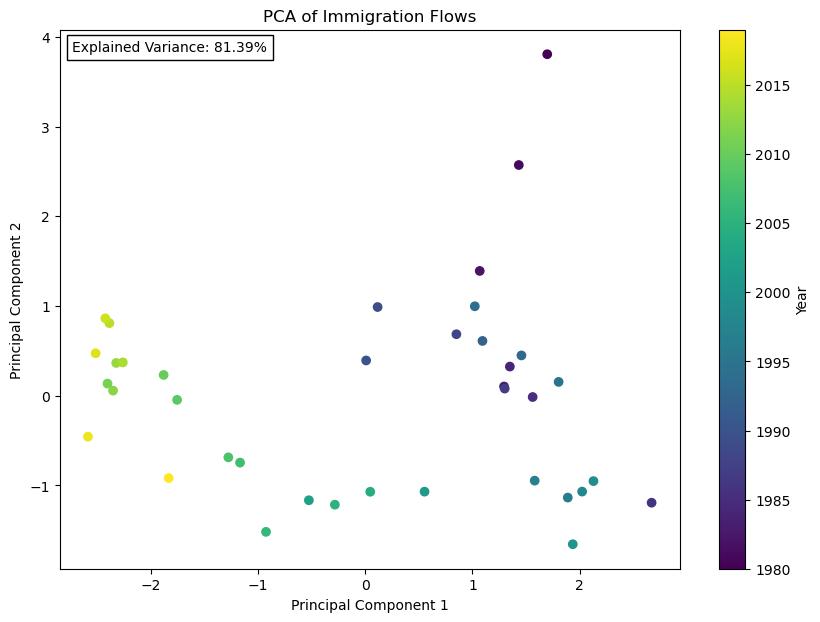

In [10]:
#plot PCA
explained = pca.explained_variance_ratio_.sum() * 100

plt.figure(figsize=(10, 7))

plt.scatter(
    immigration_pca["PC1"],
    immigration_pca["PC2"],
    c=immigration_pca["Year"]
)

plt.title("PCA of Immigration Flows")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.text(
    0.02, 0.98,
    f"Explained Variance: {explained:.2f}%",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white")
)

plt.colorbar(label="Year")

plt.show()

In [11]:
#df for PCA loadings 
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=immigration.drop(columns=["Year"]).columns
)

loadings = loadings.rename(index={
    "Immigrants Obtaining Lawful Permanent Resident Status": "Obtaintment of Permanent Residence"
})

print(loadings)

                                         PC1       PC2
Obtaintment of Permanent Residence -0.415543 -0.246663
Refugee Arrivals                    0.257686  0.714104
Noncitizen Apprehensions            0.482387 -0.479873
Noncitizen Removals                -0.510126 -0.259940
Noncitizen Returns                  0.517683 -0.362444


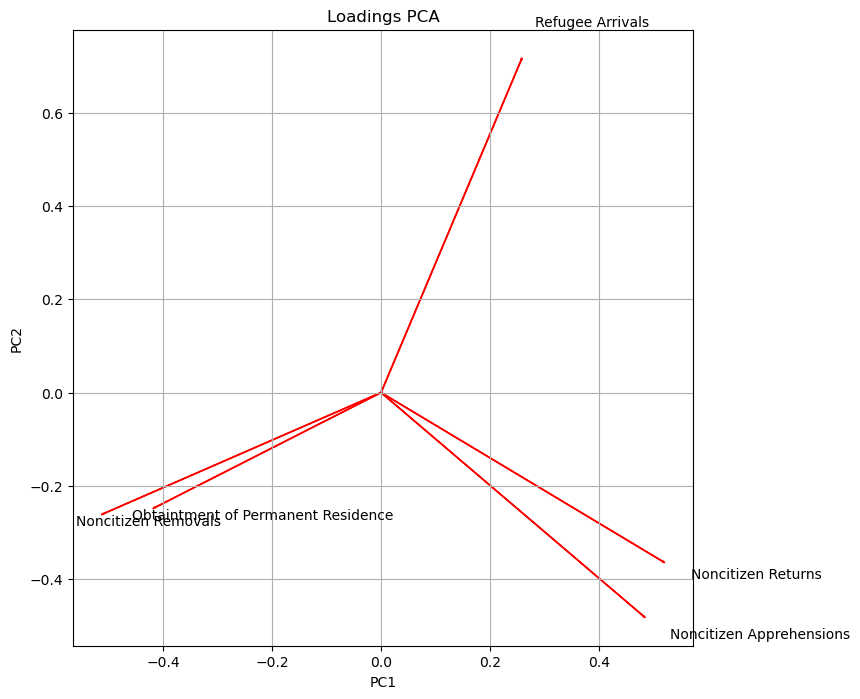

In [12]:
#plotted PCA loadings
plt.figure(figsize=(8, 8))

for feature in loadings.index:
    x = loadings.loc[feature, "PC1"]
    y = loadings.loc[feature, "PC2"]
    plt.arrow(0, 0, x, y, color="red")
    plt.text(x * 1.1, y * 1.1, feature)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Loadings PCA")
plt.grid(True)
plt.show()